# 多重パーセプトロン（MLP）で画像分類

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ARIM-ACADEMY-2026/Advanced_Tutorial_3_Keras/blob/main/1_Keras_MLP.ipynb)

Fashion-MNISTデータセットを使い、Kerasの`Sequential` APIで多重パーセプトロン（MLP）を組み立て、学習・評価するまでの流れを学びます。

## 対象読者・前提知識・動作環境・版とライセンス

- **対象読者**: Pythonの基礎文法（変数、関数、for文、リストなど）は理解しているが、Keras・TensorFlow・ニューラルネットワークの構築には初めて触れる方
- **前提知識**: 統計学・機械学習の予備知識は前提としない。「ニューラルネットワークとは何か」「損失関数とは何か」といった概念からその都度説明する
- **動作環境**: Python 3.10以降、TensorFlow 2.16以降・Keras 3系（`tensorflow.keras`は現在Keras 3を指す）。GPUがなくてもCPUで数分程度で学習が完了する規模
- **データセット**: [Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist)（Zalando Research作成、MITライセンス）。10種類の衣料品の28×28グレースケール画像、訓練6万枚・テスト1万枚
- **版**: 2026-08-03作成

## 目次

1. データの準備
2. モデルの構築
3. 学習
4. 評価とまとめ

前処理済みデータや学習済みモデルは、あとで見返せるように`output/`フォルダにも保存しますが、ノートブック自体は上から順に1回のKernelで実行する前提で書かれています。

## 教材への接続（Google Colab）

Google Colabで開いた場合は、次のセルを実行してこのリポジトリをクローンし、`module/`（共通ヘルパー関数）や`output/`・`comparison_output/`（他ノートブックとの受け渡しファイル）を含むフォルダへ移動してください。ローカル環境でこのフォルダを直接開いている場合は、次のセルは実行不要です（すでにカレントディレクトリが正しい場所になっています）。


In [ ]:
!git clone https://github.com/ARIM-ACADEMY-2026/Advanced_Tutorial_3_Keras.git
%cd Advanced_Tutorial_3_Keras


## Fashion-MNISTとは

Fashion MNISTは、画像分類の"Hello, World"としてよく使われる[MNIST](http://yann.lecun.com/exdb/mnist/)データセット（手書き数字0〜9）の代替として作られたデータセットです。画像フォーマット（28×28ピクセルのグレースケール、10クラス、訓練6万枚+テスト1万枚）はMNISTと完全に同じですが、中身は手書き数字ではなく衣料品の画像です。手書き数字は見分けが簡単すぎてモデルの実力差が出にくいため、もう少し難しい題材として作られました。

<table>
  <tr><td><img src="https://tensorflow.org/images/fashion-mnist-sprite.png" alt="Fashion MNIST sprite" width="600"></td></tr>
  <tr><td align="center"><b>図1.</b> <a href="https://github.com/zalandoresearch/fashion-mnist">Fashion-MNIST サンプル</a>（作成: Zalando Research、MITライセンス）</td></tr>
</table>

## 1. データの準備

### ステップ1: ライブラリを読み込み、乱数シードを固定する

In [ ]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')


# module/ フォルダ（このシリーズ共通のヘルパー関数）をimportできるようにする
BASE_DIR = Path.cwd()
sys.path.append(str(BASE_DIR))  # module/ はBASE_DIR直下にあるため、BASE_DIR自体をsys.pathに加える

from module.seed_utils import set_seed
from module import data_utils, viz_utils

OUTPUT_DIR = BASE_DIR / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

set_seed(42)

**コラム: なぜ最初に乱数シードを固定するのか**

ニューラルネットワークの学習には、重みの初期値や訓練データのシャッフル順序など、いたるところに乱数が使われています。シードを固定しないと、同じコードを2回実行しただけで結果（正解率やグラフ）が微妙に変わってしまい、「本のとおりに実行したのに数字が違う」という混乱の原因になります。`set_seed(42)`は`module/seed_utils.py`に用意した小さな関数で、NumPy・Python標準の`random`・TensorFlowの乱数シードをまとめて固定します（`42`という値自体に特別な意味はなく、本シリーズ共通の慣例です）。GPU上での学習は演算の並列順序の都合で完全な再現性が保証されない場合がある点には注意してください。

### ステップ2: データセットを読み込む

In [2]:
# 初回実行時はインターネットから約30MBをダウンロードし、~/.keras/ にキャッシュする。
# 2回目以降はキャッシュから読み込むため高速。
data = data_utils.load_fashion_mnist(add_channel=False, one_hot=True)

data.train_images.shape, data.test_images.shape

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


((60000, 28, 28), (10000, 28, 28))

`data_utils.load_fashion_mnist()`は、`keras.datasets.fashion_mnist`からのダウンロードに加えて、以下の前処理までまとめて行っています（中身は`module/data_utils.py`を参照）。

1. 画素値を0〜255の整数から0〜1の`float32`に正規化する
2. ラベルをone-hotベクトルに変換する（`one_hot=True`のとき）
3. `add_channel=True`ならチャネル次元を追加する（本ノートブックでは不要なので`False`）

**コラム: `SimpleNamespace`という返し方**

`data_utils.load_fashion_mnist()`は辞書でもタプルでもなく`SimpleNamespace`という入れ物でデータをまとめて返しています。`data.train_images`のように「.（ドット）」でアクセスできるので、`data[0]`のような順序依存の書き方より「何が入っているか」を読みやすくできます。関数が複数の値をまとめて返したいときに使える、覚えておくと便利なテクニックです。

### ステップ3: 画像を1枚だけ見てみる

c:\Users\japan\Dropbox\ARIM\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12521 (\N{KATAKANA LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\japan\Dropbox\ARIM\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12505 (\N{KATAKANA LETTER BE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\japan\Dropbox\ARIM\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12523 (\N{KATAKANA LETTER RU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


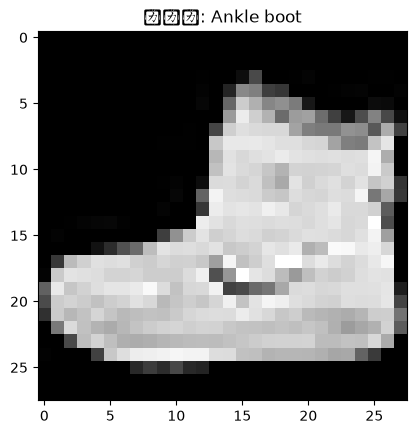

In [3]:
plt.imshow(data.train_images[0], cmap="gray")
plt.title(f"ラベル: {data.class_names[data.train_labels_int[0]]}")
plt.show()

### ステップ4: 複数の画像をまとめて見てみる（図2）

C:\Users\japan\AppData\Local\Temp\ipykernel_22180\3213182735.py:9: UserWarning: Glyph 22259 (\N{CJK UNIFIED IDEOGRAPH-56F3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\japan\AppData\Local\Temp\ipykernel_22180\3213182735.py:9: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\japan\AppData\Local\Temp\ipykernel_22180\3213182735.py:9: UserWarning: Glyph 30011 (\N{CJK UNIFIED IDEOGRAPH-753B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\japan\AppData\Local\Temp\ipykernel_22180\3213182735.py:9: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\japan\AppData\Local\Temp\ipykernel_22180\3213182735.py:9: UserWarning: Glyph 12469 (\N{KATAKANA LETTER SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\japan\AppData\Local\Temp\ipykernel_22180\3213182735.py:9: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) 

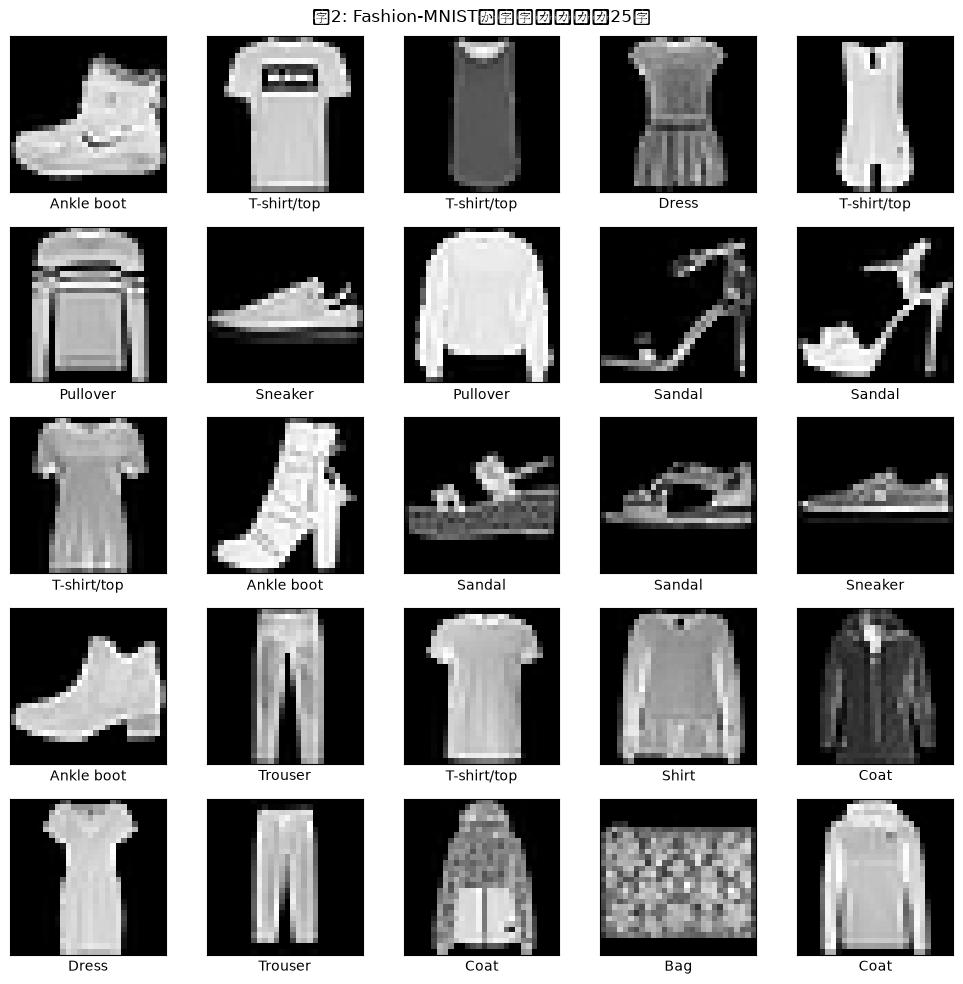

In [4]:
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(data.train_images[i], cmap="gray")
    plt.xlabel(data.class_names[data.train_labels_int[i]])
plt.suptitle("図2: Fashion-MNISTの画像サンプル25枚")
plt.tight_layout()
plt.show()

### ステップ5: 画素値の範囲を確認する（正規化）

ニューラルネットワークは、入力の値が極端に大きいと学習がうまく進まないことがあります（勾配が大きくなりすぎる、活性化関数が飽和するなど）。そこで元の画素値（0〜255の整数）を255で割り、0〜1の範囲の小数にそろえるのが「正規化」です。この処理は`data_utils.load_fashion_mnist()`の内部で既に行われています。

In [5]:
print("最小値:", data.train_images.min())
print("最大値:", data.train_images.max())
print("dtype:", data.train_images.dtype)

最小値: 0.0
最大値: 1.0
dtype: float32


### ステップ6: ラベルの形を確認する（one-hotエンコーディング）

Fashion-MNISTのラベルは、もともと「0」〜「9」の整数1つでクラスを表しています。しかし、これから作るモデルの出力層は「10個のクラスそれぞれである確率」を表す10次元のベクトルを出力します（詳しくは次節）。学習時に正解と予測を同じ形で比較できるように、正解ラベルも「正解のクラスだけ1、それ以外は0」の10次元ベクトル（one-hotベクトル）に変換しておきます。

In [6]:
print("整数ラベル（先頭5件）:", data.train_labels_int[:5])
print("one-hotラベル（先頭1件）:", data.train_labels[0])

整数ラベル（先頭5件）: [9 0 0 3 0]
one-hotラベル（先頭1件）: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


**コラム: one-hot化しない書き方もある**

Kerasには`categorical_crossentropy`（ラベルをone-hot化する必要がある）のほかに、`sparse_categorical_crossentropy`（整数ラベルのまま渡せる）という損失関数もあります。クラス数が多い・データセットが大きい場合はone-hot化がメモリを圧迫するため、実務では`sparse_categorical_crossentropy` + 整数ラベルの組み合わせもよく使われます。本ノートブックでは「one-hotエンコーディングとは何か」を明示的に学ぶ教材として、あえて`categorical_crossentropy`を使う構成にしています。

### 以降で使う変数名を整理する

以降のセルでは、`data.train_images`のように毎回書く代わりに、短い変数名（`train_images`など）を直接使います。

In [7]:
train_images, test_images = data.train_images, data.test_images
train_labels, test_labels = data.train_labels, data.test_labels
train_labels_int, test_labels_int = data.train_labels_int, data.test_labels_int
class_names = data.class_names

## 2. モデルの構築

### ステップ1: Kerasには2種類のモデルの組み方がある

Kerasで層を積む方法は主に2種類あります。

- **Sequential API**（本ノートブックで使う方法）: 層を上から下へ一本道に積み重ねる、最もシンプルな書き方。分岐や合流のないモデルに向く
- **Functional API**: 各層を「関数のように」呼び出し、入力と出力を明示的につなぐ書き方。分岐・合流のある複雑なモデルに向く

まずはSequential APIでMLPを組み立て、この後のCNNシリーズで同じ内容をFunctional APIでも書き比べます。

In [8]:
from tensorflow import keras
from keras.layers import Flatten, Dense

model = keras.Sequential()

### ステップ2: 層を1つずつ積み、そのつど`summary()`で確認する

層を追加するたびに`model.summary()`を呼び、出力の形（Output Shape）とパラメータ数（Param #）がどう変わるかを確認しながら進めます。

In [9]:
model.add(keras.Input(shape=(28, 28)))
model.add(Flatten())
model.summary()

c:\Users\japan\Dropbox\ARIM\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

`keras.Input(shape=(28, 28))`は、モデルの入り口の形を最初に明示するための特別な層です。Kerasの公式ガイドでも「あらかじめ入力形状がわかっているなら、常に明示しておくのが推奨」とされています。以前のKerasでは`Flatten(input_shape=(28, 28))`のように後続の層へ`input_shape`を渡すだけでも動きましたが、本ノートブックの検証中、この書き方だと`model.input`や`model.get_layer(...).output`（この後のAE編で使うテクニック）が`AttributeError: ... has never been called and thus has no defined input`で失敗する事例を確認したため、`keras.Input`を明示する書き方に統一しています。

`Flatten`層は、28×28の2次元画像を28×28=784個の数値が並んだ1次元ベクトルに変換するだけの層です。学習可能なパラメータはありません（Param #が0）。次の`Dense`（全結合）層は1次元ベクトルしか受け取れないため、画像を扱うMLPでは最初に必ずこの変換が必要です。

In [ ]:
model.add(Dense(128, activation="relu"))
model.summary()

`Dense(128, activation="relu")`は、784個の入力それぞれに重みを掛けて足し合わせる処理を128個並べた層です。パラメータ数は `784 × 128 + 128（バイアス項） = 100,480` と一致していることを確認してください。`relu`（Rectified Linear Unit）は、負の値を0に、正の値はそのまま通す活性化関数で、ニューラルネットワークに「非線形性」（単純な比例関係では表現できない複雑なパターン）を持たせる役割があります。

In [ ]:
model.add(Dense(64, activation="relu"))
model.summary()

In [ ]:
model.add(Dense(10, activation="softmax"))
model.summary()

出力層は`Dense(10, activation="softmax")`です。`softmax`は出力の10個の値を「合計が1になる確率」に変換する活性化関数で、「この画像がクラス$i$である確率」として10クラス分類の出力に使われる定番の組み合わせです。

**コラム: `model.summary()`をこまめに呼ぶ**

層を追加するたびに`model.summary()`を呼ぶと、各層の出力形状とパラメータ数がどう変わるか目で追えます。「次の層に渡す形状が合わない」といったエラーが起きたときも、直前の`summary()`と見比べれば原因を素早く特定できます。慣れてきたら1回にまとめても構いませんが、学習中はこまめに確認する習慣をつけると詰まりにくくなります。

### ステップ3: モデルをコンパイルする

In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

`compile()`では3つを指定します。

- **optimizer**（最適化アルゴリズム）: 損失を減らす方向にパラメータをどう更新するか。`"adam"`は多くの場面で無難に動く既定選択としてよく使われる
- **loss**（損失関数）: モデルの予測と正解のずれをどう数値化するか。10クラス分類＋one-hotラベルの組み合わせでは`"categorical_crossentropy"`を使う
- **metrics**（評価指標）: 学習中に監視したい指標。損失そのものは直感的にわかりにくいため、`"accuracy"`（正解率）もあわせて記録する

**コラム: 保存形式について**

学習済みモデルは`model.save("path.keras")`で保存し、`keras.models.load_model("path.keras")`で読み込めます。Keras 3以降は`.keras`という単一ファイル形式（モデルの構造・重み・オプティマイザの状態をまとめて1ファイルに保存する）が推奨されています。本ノートブックでは、学習が終わった後（4節）で保存の実演をします。

## 3. 学習

### ステップ1: 学習の基本用語

- **エポック（epoch）**: 訓練データ全体を1回すべて使い切ること。`epochs=30`なら、訓練データ全体を30周する
- **バッチサイズ（batch_size）**: 1回のパラメータ更新に使うデータの件数。`batch_size=128`なら128件ごとに重みを更新する。データ全体を一度に扱うより計算・メモリ効率がよく、更新の頻度も上がる
- **検証データ（validation_data）**: 学習中、各エポックの終わりにモデルの調子を確認するために使うデータ（学習そのものには使わない）

**コラム: 検証データとテストデータの違い**

本来、機械学習では「訓練データ」「検証データ」「テストデータ」の3つを分けるのが望ましいとされています。訓練中にモデルの調子を確認する検証データと、最終評価にのみ使うテストデータを分けておかないと、「検証データの推移を見ながらエポック数やアーキテクチャを調整する」という行為そのものが、間接的にテストデータの情報をモデル選択へ取り込んでしまう（本来の意味でのリーケージに近い状態になる）おそれがあるためです。

本ノートブックでは教材をシンプルに保つため、公式のKerasチュートリアルと同様にテストデータをそのまま`validation_data`として使っています。厳密な評価が必要な実務では、訓練データをさらに訓練用・検証用に分割し（`sklearn.model_selection.train_test_split`など）、テストデータは学習が終わるまで一切参照しない、という3分割構成を検討してください。

### ステップ2: 学習を実行する

In [ ]:
%%time
history = model.fit(
    train_images,
    train_labels,
    epochs=30,
    batch_size=128,
    validation_data=(test_images, test_labels),
)

**コラム: `%%time`と`%time`の違い**

`%%time`（パーセントが2つ）はセル全体の実行時間を計測するJupyterのマジックコマンドです。`%time`（1つ）は次の1行だけを計測します。`history = model.fit(...)`のように複数行にまたがるコードを書くときは`%%time`を使い、セルの一番先頭に置く必要がある点に注意してください（途中の行に書いても効果がありません）。

## 4. 評価とまとめ

### ステップ1: 損失関数の値と正解率の最終値を確認する

In [ ]:
train_loss_mlp, train_acc_mlp = model.evaluate(train_images, train_labels, verbose=0)
test_loss_mlp, test_acc_mlp = model.evaluate(test_images, test_labels, verbose=0)

print("訓練データの損失関数の値:", train_loss_mlp)
print("テストデータの損失関数の値:", test_loss_mlp)
print("訓練データの分類精度:", train_acc_mlp)
print("テストデータの分類精度:", test_acc_mlp)

**コラム: 評価指標は使い回さず、専用の変数名で保持する**

`train_loss_mlp`のように、モデル名（`mlp`）を変数名に含めています。これは面倒に見えて重要な習慣です。この後のCNNシリーズでも同じ`model.evaluate()`を使いますが、変数名を`train_loss`のまま使い回すと、複数モデルを比較する表を作るときに前の値が上書きされて消えてしまいます。1つの実験につき1つの変数名、という原則を徹底しておくと、後から「あの実験の数字は何だったか」を安全に参照できます。

### ステップ2: 学習曲線を可視化する（図3・図4）

In [ ]:
viz_utils.plot_metric_curve(history, metric="loss", fig_num=3, output_dir=OUTPUT_DIR)

In [ ]:
viz_utils.plot_metric_curve(history, metric="accuracy", fig_num=4, output_dir=OUTPUT_DIR)

訓練データ（黒線）と検証データ（赤線、実質はテストデータ）の曲線が同じように下がり続けていれば順調です。訓練側だけがよくなり続け、検証側が頭打ち・悪化に転じている場合は「過学習」（訓練データを覚えすぎて未知データへの対応力が落ちている状態）のサインです。

### ステップ3: 混同行列を確認する（図5）

In [ ]:
test_pred_proba_mlp = model.predict(test_images, verbose=0)
test_pred_class_mlp = np.argmax(test_pred_proba_mlp, axis=1)

cm_mlp = viz_utils.plot_confusion_matrix(
    test_labels_int, test_pred_class_mlp,
    class_names=class_names, fig_num=5, output_dir=OUTPUT_DIR,
)

混同行列は「正解クラス（行）に対して、モデルがどのクラスと予測したか（列）」を表にしたものです。対角線上のマス（正解＝予測）に数字が集中していれば良好です。対角線から外れた箇所に大きな値がある場合、そのクラスの組み合わせを混同しやすいことがわかります（例えば"Shirt"と"T-shirt/top"はどちらも上半身の衣類で似ているため、混同しやすい傾向があります）。

`confusion_matrix(y_true, y_pred)`は「正解が先、予測が後」という引数順序がscikit-learnの規約です。順序を逆にすると、行と列が入れ替わった、見た目は似ているが意味の異なる表になってしまうので注意してください。

### ステップ4: 学習済みモデルを保存する

In [ ]:
model_path = OUTPUT_DIR / "mlp_trained.keras"
history_path = data_utils.save_history(OUTPUT_DIR, "history_mlp.npz", history)
model.save(model_path)
print("保存しました:", model_path, "/", history_path)

後から見返すときやこの後のCNNシリーズと結果を比べるときのために、学習済みモデルと学習履歴を`output/`フォルダに保存しておきます。

### ステップ5: モデル比較表に記録する

In [ ]:
import csv

COMPARISON_DIR = BASE_DIR.parent / "comparison_output"
COMPARISON_DIR.mkdir(exist_ok=True)
comparison_path = COMPARISON_DIR / "classification_comparison.csv"

row = {
    "model": "MLP",
    "api_style": "Sequential",
    "dataset": "Fashion-MNIST",
    "test_loss": test_loss_mlp,
    "test_acc": test_acc_mlp,
}

file_exists = comparison_path.exists()
with open(comparison_path, "a", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=list(row.keys()))
    if not file_exists:
        writer.writeheader()
    writer.writerow(row)

print(f"記録先: {comparison_path}")

この`classification_comparison.csv`は、本ノートブックが置かれた`1_Keras_MLP/`フォルダの外（`code/comparison_output/`）に保存します。理由は、このファイルがMLP単独の成果物ではなく、**MLPとCNN（Sequential・Functional）という複数のノートブックをまたいだ比較**のためのファイルだからです。CNNのノートブックでこのファイルに行が追記され、「MLPよりCNNの方がFashion-MNISTの分類精度が高い」という、モデルを比較するときによくある結論を実際の数値で確認できるようになります。

**コラム: なぜ`output/`ではなく`comparison_output/`に保存するのか**

コーディング規約では生成物を`output/`サブフォルダに保存するルールになっていますが、それは「1冊のノートブックの中で完結する成果物」の話です。複数のノートブックをまたいで参照するファイルは、どのノートブックにも属さない共有の場所に置いたほうが、依存関係がわかりやすくなります。

## まとめ

- Fashion-MNIST（10クラス・28×28グレースケール画像）を、Kerasの`Sequential` APIで組んだ多重パーセプトロン（`Flatten → Dense(128) → Dense(64) → Dense(10, softmax)`）で分類した
- 学習には`categorical_crossentropy`損失・`adam`オプティマイザを使用し、30エポック学習させた
- 混同行列から、視覚的に似ている衣類カテゴリ同士（例: Shirt と T-shirt/top）が混同されやすい傾向を確認した
- 学習済みモデルと評価結果を`output/`・`comparison_output/`に保存し、この後のCNNシリーズと比較できるようにした

## 本ノートブックで扱っていないこと（今後の課題）

- ハイパーパラメータ（層の数、ユニット数、学習率など）を体系的に探索するチューニング
- 検証データとテストデータを分離した、厳密な3分割評価（3節ステップ1のコラム参照）
- 画像特有の構造（隣接する画素同士の関係）を利用しないシンプルなMLPの限界。この点は次の`2_Keras_CNN_Sequential-API.ipynb`で畳み込み層を導入して補う

## 演習問題

1. `Dense(128)`を`Dense(256)`に変えると、パラメータ数と最終的な正解率はどう変わるか確認しなさい。
2. `epochs`を10に減らして学習し直し、学習曲線（図3・図4相当）が30エポックのときとどう違うか比較しなさい。
3. 混同行列（図5）から、最も混同されやすいクラスの組み合わせを2つ挙げ、画像を実際に見比べてその理由を考察しなさい。
4. `sparse_categorical_crossentropy`と整数ラベルの組み合わせに書き換え、`categorical_crossentropy`＋one-hotラベルの場合と結果が一致することを確認しなさい（1節ステップ6コラム参照）。